# Setup

In [1]:
from torch_harmonics.circular_harmonics import CircularHarmonics

In [2]:
L = 2
ch = CircularHarmonics(L)

# Plotting the Circular Harmonics

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from torch_harmonics import plotting

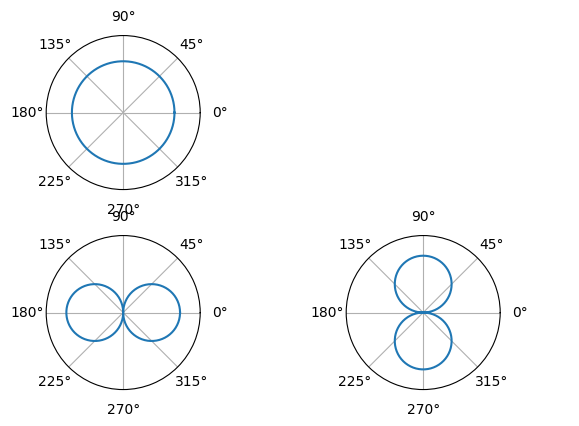

In [4]:
fig = plt.figure(figsize=(6,L*2))
subfigs = fig.subfigures(L, 2)

for l in range(L):
    for i in range(2):
        # L=0 is a scalar
        if l == 0 and i == 1:
            continue
        # L>0 has a cos and sin component
        lmax_index = max(0, 2*l - 1)
        plotting.plot_circular_fn(np.abs(ch.basis_fns[lmax_index+i].numpy()), fig=subfigs[l,i])

# Circular Harmonics Transform

In [5]:
import torch
from torch import nn

In [17]:
x = torch.linspace(0,2*np.pi, 360)
y = torch.cos(x) + 2 * torch.sin(x) + torch.cos(10*x)

<PolarAxes: >

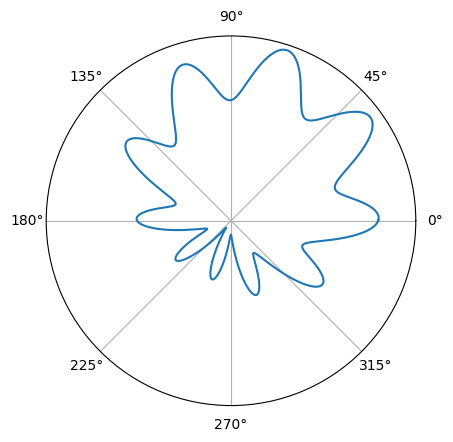

In [18]:
plotting.plot_circular_fn(y.numpy())

In [46]:
class CHT(nn.Module):
    def __init__(self, L=3, num_phi=360):
        super().__init__()
        self.w_lin = nn.Linear(num_phi, L*2-1)
        self.ch = CircularHarmonics(L)

    def forward(self, x):
        w = self.w_lin(x)
        print(w.detach().numpy().round(1))
        return self.ch(w)

In [47]:
ch_model = CHT(11)
optimizer = torch.optim.Adam(ch_model.parameters(), lr = 1e-3)

for iter in range(100):
    loss = (ch_model(y.view(1,-1)) - y).pow(2).mean()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if iter % 10 == 0:
        print(f'iteration: {iter} loss: {loss.item()}')

[[-1.2  0.2 -0.3 -1.6 -0.4 -1.4  0.6  0.8 -1.   0.3 -0.4 -1.1 -1.2 -0.2
  -1.3 -0.6  0.8  1.2 -0.6  0.4 -0.8]]
iteration: 0 loss: 5.5843186378479
[[-0.7  0.8  0.3 -1.   0.1 -0.8  0.   0.3 -0.4 -0.2  0.2 -0.6 -0.7  0.3
  -0.8 -0.   0.3  0.6 -0.1  0.9 -0.3]]
[[-0.1  1.3  0.8 -0.5  0.4 -0.3 -0.3 -0.2  0.1 -0.2  0.3 -0.1 -0.2  0.2
  -0.3  0.4 -0.2  0.1  0.3  1.4  0.2]]
[[ 0.3  1.8  1.3 -0.   0.3  0.1 -0.4 -0.5  0.4 -0.   0.2  0.3  0.3 -0.
   0.2  0.5 -0.5 -0.3  0.5  1.9  0.5]]
[[ 0.6  2.2  1.9  0.4  0.1  0.5 -0.3 -0.5  0.6  0.1  0.   0.6  0.5 -0.2
   0.5  0.3 -0.5 -0.6  0.4  2.2  0.5]]
[[ 0.7  2.4  2.4  0.6 -0.1  0.7 -0.1 -0.4  0.6  0.2 -0.2  0.7  0.7 -0.2
   0.7  0.1 -0.4 -0.7  0.2  2.5  0.4]]
[[ 0.7  2.6  2.8  0.8 -0.2  0.7  0.1 -0.2  0.4  0.1 -0.2  0.6  0.7 -0.1
   0.7 -0.1 -0.3 -0.6 -0.   2.5  0.2]]
[[ 0.5  2.6  3.3  0.8 -0.2  0.7  0.2 -0.   0.2 -0.  -0.2  0.4  0.6 -0.
   0.6 -0.2 -0.1 -0.5 -0.2  2.5  0. ]]
[[ 0.3  2.5  3.7  0.7 -0.1  0.6  0.3  0.1  0.  -0.1 -0.1  0.2  0.4  0.1
   0.5 

[[-0.   1.8  3.6 -0.   0.   0.   0.   0.  -0.  -0.  -0.  -0.  -0.  -0.
   0.   0.  -0.  -0.   0.   1.8  0. ]]


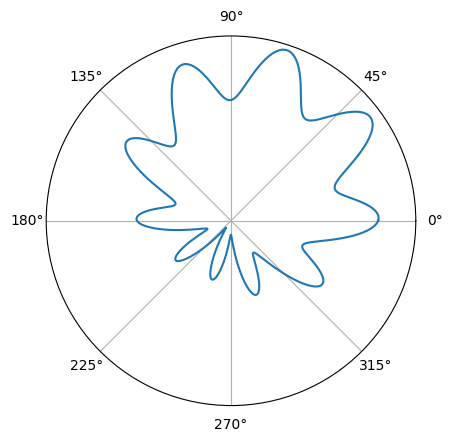

In [48]:
with torch.no_grad():
    pred = ch_model(y.view(1,-1))
    plotting.plot_circular_fn(pred.squeeze().numpy())